In [ ]:


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

# Configuración visual
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
# --------------------------------------------
# 1. Carga del dataset
# --------------------------------------------
df = sns.load_dataset("penguins").copy()

In [3]:
# --------------------------------------------
# 1. Selección de variables numéricas
# --------------------------------------------
vars_numericas = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

df_num = df[vars_numericas].copy()

In [4]:
# --------------------------------------------
# 2. Cálculo de la matriz de correlaciones
# --------------------------------------------
corr_matrix = df_num.corr(method="pearson")

print("Matriz de correlaciones:")
display(corr_matrix)

Matriz de correlaciones:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.00,-0.24,0.66,0.60
bill_depth_mm,-0.24,1.00,-0.58,-0.47
flipper_length_mm,0.66,-0.58,1.00,0.87
body_mass_g,0.60,-0.47,0.87,1.00


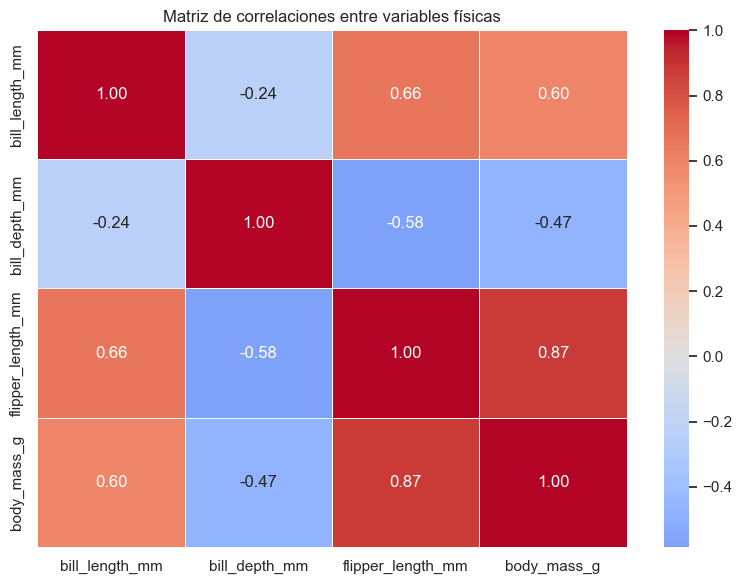

In [5]:
# --------------------------------------------
# 3. Heatmap de correlaciones
# --------------------------------------------
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Matriz de correlaciones entre variables físicas")
plt.tight_layout()
plt.show()

In [6]:
# --------------------------------------------
# 4. Identificación de correlaciones más relevantes
# --------------------------------------------
# Convertimos la matriz en formato largo
corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["Variable_1", "Variable_2", "Correlacion"]

# Ordenamos por valor absoluto
corr_pairs["Abs"] = corr_pairs["Correlacion"].abs()
corr_pairs_sorted = corr_pairs.sort_values(by="Abs", ascending=False)

print("\nCorrelaciones ordenadas por magnitud:")
display(corr_pairs_sorted[["Variable_1", "Variable_2", "Correlacion"]])


Correlaciones ordenadas por magnitud:


,Variable_1,Variable_2,Correlacion
5,flipper_length_mm,body_mass_g,0.87
1,bill_length_mm,flipper_length_mm,0.66
2,bill_length_mm,body_mass_g,0.60
3,bill_depth_mm,flipper_length_mm,-0.58
4,bill_depth_mm,body_mass_g,-0.47
0,bill_length_mm,bill_depth_mm,-0.24


In [7]:
# --------------------------------------------
# 5. Correlación inversa más fuerte
# --------------------------------------------
corr_negativas = corr_pairs[corr_pairs["Correlacion"] < 0]

if not corr_negativas.empty:
    corr_inv = corr_negativas.sort_values(by="Correlacion").iloc[0]
    
    print("\nCorrelación inversa más fuerte:")
    print(f"{corr_inv['Variable_1']} - {corr_inv['Variable_2']} : {corr_inv['Correlacion']:.2f}")
else:
    print("\nNo hay correlaciones negativas relevantes.")


Correlación inversa más fuerte:
bill_depth_mm - flipper_length_mm : -0.58
